In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from SynFileUtils import SynFileReader

In [5]:
normalized_suffix = pd.read_csv("/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/normalized_suffix.tsv", sep='\t')
normalized_suffix.head()

,sentence_id,synonym_id,matched_text,start_position,hit_length,synonym,prefix,suffix,matched_suffix,mature_mirna_suffix
0,chunk_09.sent:PMC6469024.6.45,0:0,miR,13,3,miR,NaN,-708,-708,NaN
1,chunk_09.sent:PMC6469024.6.47,0:0,miR,12,3,miR,NaN,-708,-708,NaN
2,chunk_09.sent:PMC6469024.7.3,0:0,miR,75,3,miR,NaN,-708-mediated,-708,NaN
3,chunk_09.sent:PMC6469071.6.11,0:0,miR,162,3,miR,ssc-,-4331,-4331,NaN
4,chunk_09.sent:PMC6469073.5.22,0:0,miR,152,3,miR,NaN,"-509-5p,",-509,-5p


In [ ]:
with SynFileReader('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/synoyms/mir_regex.syn', low_memory=False) as reader:
    split_values = normalized_suffix["synonym_id"].str.split(":").str[1]
    line_numbers = split_values.astype(int)
    syn_series = pd.Series(reader.id_list)
    normalized_suffix['synonym_id'] = line_numbers.map(syn_series)

In [6]:
normalized_suffix["combined"] = normalized_suffix['normalized_synonym'] + normalized_suffix['matched_suffix']
normalized_suffix["combined"] = normalized_suffix["combined"].str.replace(r"[^a-zA-Z0-9-]+", "-", regex=True) 

KeyError: 'normalized_synonym'

In [5]:
normalized_suffix.head()

,sentence_id,synonym_id,matched_text,start_position,hit_length,synonym,prefix,suffix,matched_suffix,mature_mirna_suffix,normalized_synonym,combined
0,chunk_09.sent:PMC6469024.6.45,0:0,miR,13,3,miR,NaN,-708,-708,NaN,mir,mir-708
1,chunk_09.sent:PMC6469024.6.47,0:0,miR,12,3,miR,NaN,-708,-708,NaN,mir,mir-708
2,chunk_09.sent:PMC6469024.7.3,0:0,miR,75,3,miR,NaN,-708-mediated,-708,NaN,mir,mir-708
3,chunk_09.sent:PMC6469071.6.11,0:0,miR,162,3,miR,ssc-,-4331,-4331,NaN,mir,mir-4331
4,chunk_09.sent:PMC6469073.5.22,0:0,miR,152,3,miR,NaN,"-509-5p,",-509,-5p,mir,mir-509


In [6]:
counts = normalized_suffix['combined'].value_counts()
counts.head(30)

combined
mir-21      317724
mir-155     190266
mir-34a     139711
mir-146a    130821
mir-145      99271
mir-122      96890
mir-124      89855
mir-223      82312
let-7        79262
mir-126      75732
mir-221      73052
mir-17       72234
mir-125b     69086
mir-9        65685
mir-29a      63173
mir-1        62287
mir-143      61600
mir-16       61414
mir-210      59864
mir-214      56712
mir-181a     54586
mir-150      53520
mir-27a      53395
mir-29b      52295
mir-26a      52260
mir-7        52253
mir-199a     52127
mir-200c     51670
mir-142      51084
mir-375      50199
Name: count, dtype: int64

In [ ]:
precursors = pd.read_csv('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/mirbase/precursors_no_prefix.txt', sep='\t')
families = pd.read_csv('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/mirbase/mirna_prefam.txt', sep='\t')

1983

In [33]:
# Get all families where 'mirna_id' is NOT in the precursors 'name' column
families_not_precursors = families[~families['mirna_id'].isin(precursors['name'])]

# Extract just the unique family names/IDs from that result
unique_family_names = families_not_precursors['mirna_id'].unique()
unique_family_names

<StringArray>
[  'mir-30', 'MIR169_1',  'mir-515', 'MIR167_1', 'MIR171_1', 'MIR169_2',
   'MIR478',  'mir-368',   'MIR439', 'MIR171_2',
 ...
 'mir-8524', 'mir-5838', 'mir-9300', 'mir-9791',  'MIR9662', 'mir-9786',
 'mir-8303', 'mir-9457',  'MIR9552', 'mir-8815']
Length: 802, dtype: str

In [29]:
mirna_name_set = set(families['mirna_id'].str.lower())
#mirna_name_set.update(precursors['name'].str.lower())
len(mirna_name_set)

1983

In [ ]:
counts_df = counts.reset_index(name='mention_count')
counts_df['is_in_mirbase'] = counts_df['combined'].isin(mirna_name_set)
false_entries = counts_df[~counts_df['is_in_mirbase']]
# View the top 30 with the new column included
print(f"In total {counts_df['mention_count'].sum()} mirna entites.")
print(f"{false_entries['mention_count'].sum()} could not be normalized.")
false_entries.to_csv('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/mirbase/delete.txt', sep='\t', index=False)

In total 9326140 mirna entites.
9284942 could not be normalized.


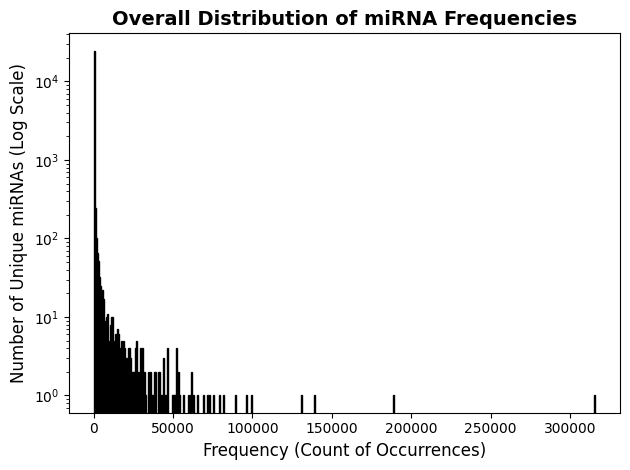

In [35]:

# Plotting the distribution of the numbers themselves
plt.hist(counts, bins=500, color='skyblue', edgecolor='black')

plt.yscale('log') 

plt.title('Overall Distribution of miRNA Frequencies', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Count of Occurrences)', fontsize=12)
plt.ylabel('Number of Unique miRNAs (Log Scale)', fontsize=12)
plt.tight_layout()

plt.show()